# Deconvolution

In [609]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [610]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv, sample_identification
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
import dbscan_peak
from whittaker_eilers import WhittakerSmoother
import deconvolution


In [ ]:
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'
chromato, time_rn=read_only_chroma(filename, mod_time=1.7)

Loaded 48756004 mass values
Non-finite mass values: 0
[]
[]


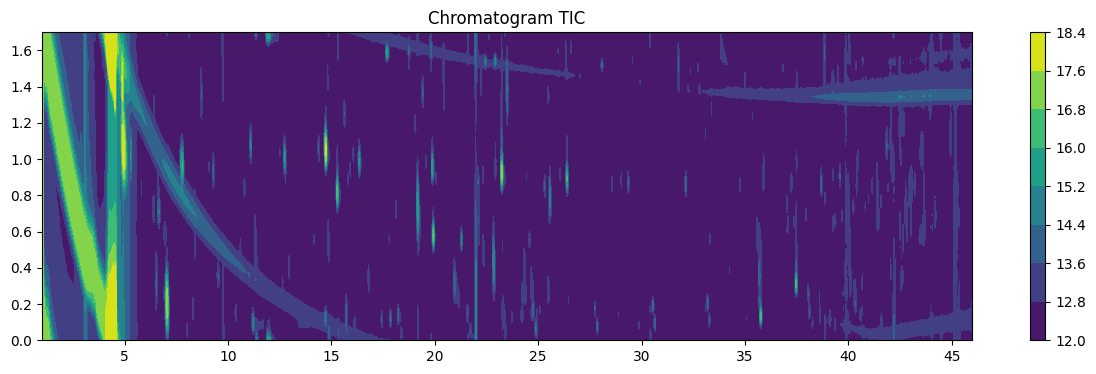

chromato read 11.615240812301636 s
--- 61.11738419532776 seconds --- to compute full spectra centroid
full spectra computed 63.27072739601135 s


In [611]:
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="D:/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename='D:/cdf centroid/B-A-009-751353-gauche-ReCIVA.cdf'
#filename='D:/cdf centroid/B-K-031-751355-Tedlar.cdf'
filename="D:/DC volatil cf 8/2025-04-16_751318_QCnew23EI.cdf"
filename = "D:/GCxGC/gamme/751343_gamme_1ppm.cdf"
#filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'

chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=False)

In [4]:
chromato_cube = chromato_cube[:400,:,:]

In [612]:
print("baseline correction")
import baseline_correction 
#baseline_cube = np.array([correct_per_mass(chromato_cube[m,:,:]) for m in range(chromato_cube.shape[0])[:10]]) # multiprocess 
baseline_cube=np.array(baseline_correction.chromato_cube_corrected_baseline(chromato_cube))

baseline correction


In [630]:
print("start peak detection")
results= dbscan_peak.detect_peak_dog_mp(baseline_cube,500,
                       0.0001,
                       5,
                       1, 3,
                       1.5,
                       0.5,multi_processing=True)

start peak detection


In [635]:
print("cluster per mass")
coordinate = [x[0] for x in results ]
radius=[x[1] for x in results  ]
coordinate_cluster, radius=dbscan_peak.cluster_per_mass(coordinate,radius,baseline_cube,chromato_cube,time_rn,1.7,rt1_delta=5, rt2_delta=0.1,thr_debscan=0.03,max_peak_per_mass=400)    

cluster per mass


In [636]:
print(str(np.sum([len(x) for x in coordinate_cluster]))+ " peaks")

10241 peaks


In [637]:
print("deconvolution per mass")
quanti=deconvolution.deconvolution(baseline_cube, time_rn, 1.7, coordinate_cluster, radius,multi_processing=True)
# quanti=[]
# for m in range(baseline_cube.shape[0])[:200]:
#     print(m)
#     quanti.append(deconvolution.deconvolution_per_mass(coordinate_cluster[m], radius[m], baseline_cube[m,:,:],time_rn,1.7,plot_deconvo=False))

#quanti = [res for res in quanti if res is not None]
quanti_all_mass=[]
for m,elt in enumerate(quanti):
    if(len(elt[0])>0):
        for x,y in elt:
            quanti_all_mass.append([m,x,y])
coordinates_all_mass=[]
for elt in coordinate_cluster:
    for x,y in elt:
        coordinates_all_mass.append([x,y])
len(coordinates_all_mass)

deconvolution per mass


10241

In [638]:
print("compute distance metric "+ str(len(coordinates_all_mass)) + " peaks")
mod_time=1.7
distance_matrix=dbscan_peak.compute_distance_metric(np.array(coordinates_all_mass),baseline_cube,mod_time,time_rn,rt1_delta=2, rt2_delta=0.02)

compute distance metric 10241 peaks


In [639]:
print("clustering")
coordinates, coordinates, clusters, label= dbscan_peak.cluster_peak(distance_matrix,chromato,coordinates_all_mass,coordinates_all_mass,thr_debscan=0.04,min_sample_db_scan=3)
len(coordinates)

clustering


779

In [640]:
# merge peaks cut but the modulation
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, mod_time, chromato.shape)

# 1.Identifier les lignes à supprimer (bound = up_bound + low_bound)
mask = (coordinates_in_chromato[:, 1] > (mod_time-0.05)) | (coordinates_in_chromato[:, 1] < 0.05)
bound= coordinates[mask]

# 2.cluster without RT2 penalty 
distance_matrix=dbscan_peak.compute_distance_metric(bound,chromato_cube,mod_time,time_rn,rt1_delta=mod_time, rt2_delta=100000)
bound_cluster, bound_cluster,clusters_bound,label_bound= dbscan_peak.cluster_peak(distance_matrix,chromato,bound,bound,thr_debscan=0.02,min_sample_db_scan=2)
if all([len(x)==2 for x in clusters_bound]) :
    # 3. replace cluster 
    label_f=[]
    index_delete=[]
    for x,y in [x for x in label_bound if len(x)==2]:
        index1=np.where(mask)[0][x]
        index2=np.where(mask)[0][y]
        label_new= label[index1] + label[index2]
        label_f.append(label_new)
        index_delete.append(index1)
        index_delete.append(index2)

    label = [x for j,x  in enumerate(label) if j not in index_delete]+ label_f
    coordinates =  np.concatenate((np.array([x for i, x in enumerate(coordinates) if i not in index_delete]), bound_cluster), axis=0)
    print(len(label_f)) # ajouter pics coupé dans les meme cluster 

13


In [641]:
sepc_list, area = deconvolution.construct_spectrum(quanti_all_mass,label,baseline_cube.shape[0])

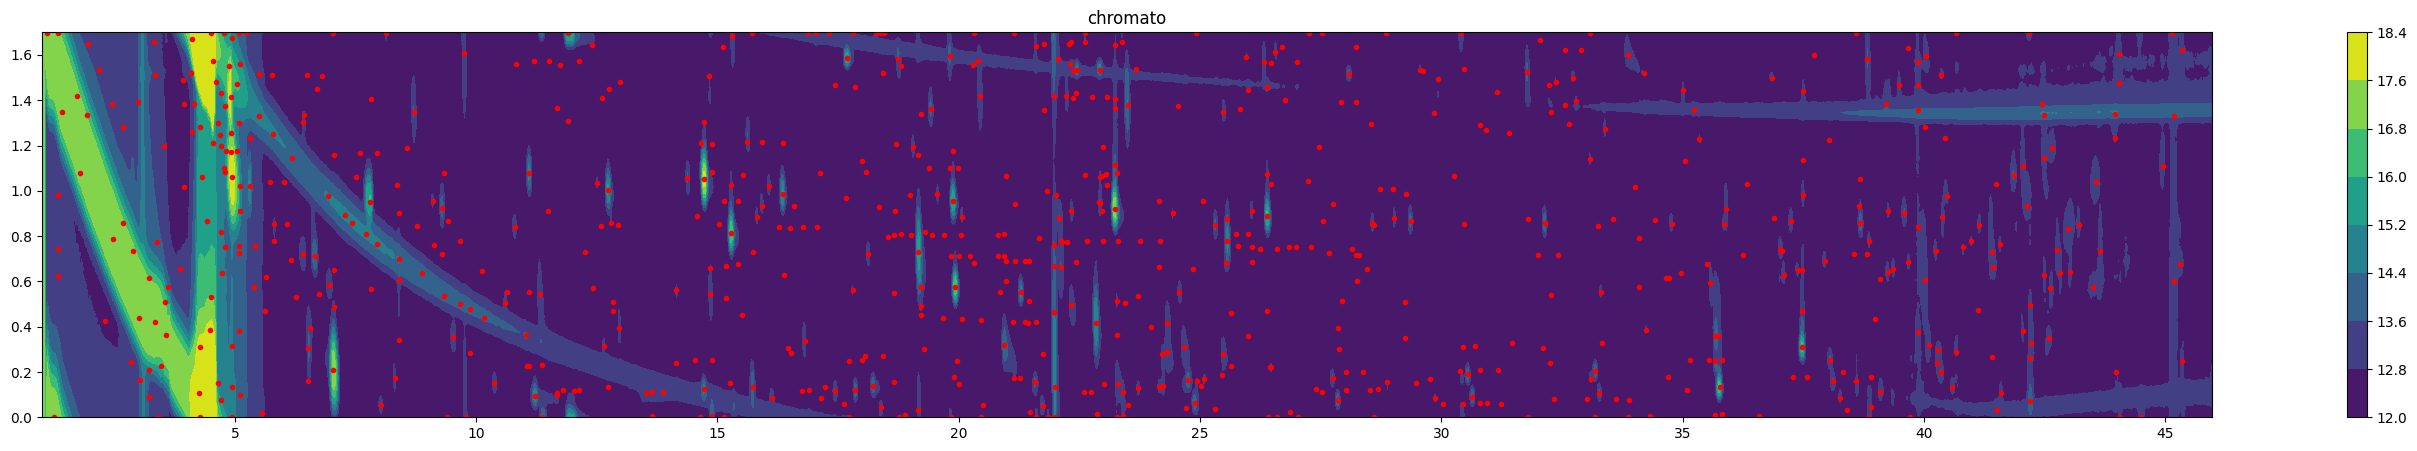

In [642]:
plt.rcParams['figure.figsize'] = [35, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

In [643]:
import pandas as pd
import logging
import pyms
import pyms_nist_search
import matching

matches = matching.matching_nist_lib_from_chromato_cube(
            (chromato, time_rn, mass_range), baseline_cube, coordinates,
            mod_time=1.7,
            match_factor_min=700, nist=False)

def matching_from_spectra(spectra):
    search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

    logger=logging.getLogger('pyms_nist_search')
    logger.setLevel('ERROR')
    logger=logging.getLogger('pyms')
    logger.setLevel('ERROR')
    masses=  np.arange(35, len(spectra)+35)

    mass_spectrum = pyms.Spectrum.MassSpectrum(masses, spectra)
    hits = search.full_search_with_ref_data(mass_spectrum, n_hits=5)
    return hits

import warnings
warnings.filterwarnings("ignore")
test=[]
for item in (sepc_list):
    test.append(matching_from_spectra(item)[0][0].match_factor)
test2=[]
for item in (matches):
    test2.append(matching_from_spectra(item[1][0]['spectra'] )[0][0].match_factor)

NIST skipped


775.0
739.5


(array([ 3.,  1.,  2.,  1.,  4.,  8.,  6.,  4.,  8.,  7., 12., 20.,  7.,
        16.,  9.,  8.,  9., 20., 11., 13., 22., 21., 21., 16., 17., 13.,
        11., 12.,  7., 12., 17., 12., 10.,  8.,  8., 14., 14., 16., 12.,
        10., 19., 12., 13., 16.,  7., 19., 10., 10.,  6.,  6.]),
 array([489. , 498.6, 508.2, 517.8, 527.4, 537. , 546.6, 556.2, 565.8,
        575.4, 585. , 594.6, 604.2, 613.8, 623.4, 633. , 642.6, 652.2,
        661.8, 671.4, 681. , 690.6, 700.2, 709.8, 719.4, 729. , 738.6,
        748.2, 757.8, 767.4, 777. , 786.6, 796.2, 805.8, 815.4, 825. ,
        834.6, 844.2, 853.8, 863.4, 873. , 882.6, 892.2, 901.8, 911.4,
        921. , 930.6, 940.2, 949.8, 959.4, 969. ]),
 <BarContainer object of 50 artists>)

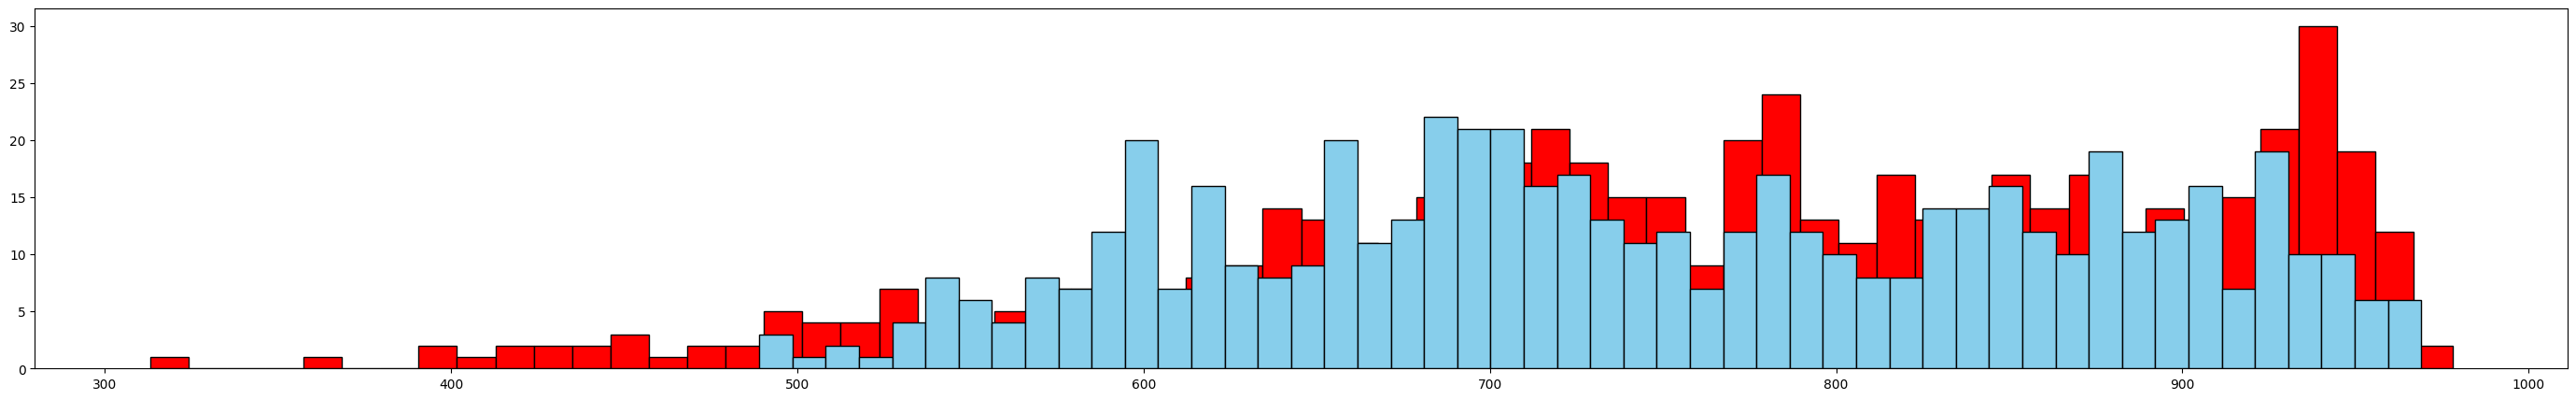

In [644]:
print(np.median([x for j,x in enumerate(test) if coordinates_in_chromato[j][0]<30 ]))
print(np.median([x for j,x in enumerate(test2) if coordinates_in_chromato[j][0]<30 ]))
plt.hist([x for j,x in enumerate(test) if coordinates_in_chromato[j][0]<30 ], bins=60, color='red', edgecolor='black')
plt.hist([x for j,x in enumerate(test2) if coordinates_in_chromato[j][0]<30 ], bins=50, color='skyblue', edgecolor='black')


In [670]:
import plotly.graph_objects as go
import numpy as np
import kaleido
i=7
# Example spectra data
# Replace these with your actual spectra arrays
spectrum2 = sepc_list[i]  # First spectrum for bar plot
spectrum1 = matches[i][1][0]['spectra'] # Second spectrum for line plot
# Generate x-axis values
x_values = np.arange(len(spectrum1))+35
# Create the bar plot for the first spectrum
bar_trace = go.Bar(x=x_values, y=spectrum1, name='Original Spectrum')
# Create the line plot for the second spectrum
line_trace = go.Scatter(x=x_values, y=spectrum2, mode='lines', name='Estimated Spectrum', line=dict(color='red'))
# Combine both plots
fig = go.Figure(data=[bar_trace, line_trace])
fig

In [671]:
print(matching_from_spectra(sepc_list[i])[0][0])
matching_from_spectra(matches[i][1][0]['spectra'])[0]

Search Result: Benzene 	(961)


(Search Result: Benzene 	(963), Reference Data: Benzene 	(71-43-2))

In [665]:
print(matches[i][0])
coordinates_in_chromato[i]

[7.0350000584, 1.695]


array([7.03500006, 1.695     ])

In [268]:
[j for j,x in enumerate(coordinates_in_chromato) if 25.55<x[0]<25.65 and 0.3<x[1]<0.5]

[64, 138, 591]

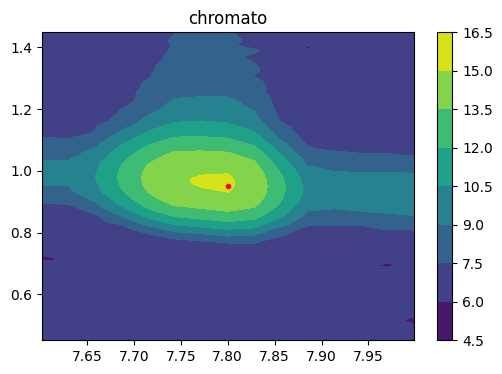

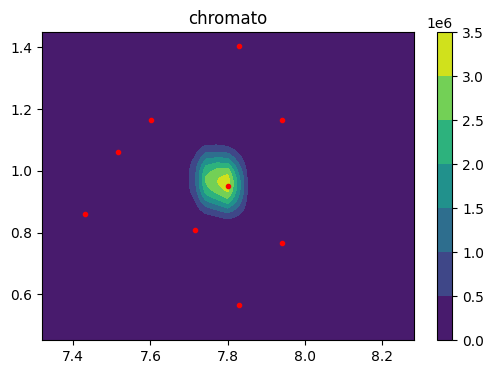

In [674]:
plt.rcParams['figure.figsize'] = [6, 4]
m=78
plot.visualizer2((chromato_cube[m-35,:,:], time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=np.array([coordinates_in_chromato[i]]), 
                 rt1=coordinates_in_chromato[i][0],rt2=coordinates_in_chromato[i][1], rt1_window=0.2, rt2_window=0.5)
plot.visualizer2((baseline_cube[m-35,:,:], time_rn), title="chromato", log_chromato=False,  mod_time=1.7,points=coordinates_in_chromato, 
                 rt1=coordinates_in_chromato[i][0],rt2=coordinates_in_chromato[i][1], rt1_window=0.5, rt2_window=0.5)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ouverture du pdf
with PdfPages("D:/chromato_results4.pdf") as pdf:

    for m in range(chromato.shape[0])[224:]:  
        print(f"Processing m={m}")

        correct= baseline_correct(chromato_cube[m,:,:],block_size=20,gamma=0.25, lmbd=15)
        correct= smooth2d(correct, lmbd=1, lmbd2=1)
        
        coordinate_before, radius = detect_peak_dog(
            correct, abs_threshold=500, rel_threshold=0.001,
            noise_factor=5, min_sigma=1, max_sigma=3,
            sigma_ratio=1.1, overlap=0.5
        )

        # ========== Peak clustering ==========
        if(len(coordinate_before)>0):
            distance_matrix = dbscan_peak.compute_distance_metric(coordinate_before, chromato_cube, 1.7, time_rn, 5, 0.1)
            clustering = DBSCAN(eps=0.03, min_samples=1, metric='precomputed').fit(distance_matrix)
            labels = clustering.labels_
            unique_labels = set(labels)
            unique_labels.discard(-1)
            ncluster = len(unique_labels)

            clusters = [[] for _ in range(ncluster)]
            for i in range(len(coordinate_before)):
                clusters[clustering.labels_[i]].append(([coordinate_before[i], radius[i]]))

            coordinates, radius_new = [], []
            for cluster in clusters:
                if len(cluster) > 1:
                    idx = np.argmax(np.array([chromato[coord[0][0], coord[0][1]] for coord in cluster]))
                    coord = cluster[idx][0]
                    rad = cluster[idx][1]
                else:
                    coord = cluster[0][0]
                    rad = cluster[0][1]
                coordinates.append(coord)
                radius_new.append(rad)
            coordinates = np.array(coordinates)

            # ========== Création des deux plots sur la même figure ==========
            fig, axes = plt.subplots(2, 1, figsize=(30, 10))

            # --- Plot 1 : contour avec points
            contour = axes[0].contourf(np.log(correct.T))
            plt.colorbar(contour, ax=axes[0])
            axes[0].set_title(f"m={m} - Contour")
            axes[0].plot(coordinate_before[:,0], coordinate_before[:,1], "b.")
            axes[0].plot(coordinates[:,0], coordinates[:,1], "r.")

            # --- Plot 2 : visualisation cluster
            chromato_safe = np.where(
                chromato_cube[m,:,:] <= 0,
                np.min(chromato_cube[m,:,:][chromato_cube[m,:,:] > 0]),
                chromato_cube[m,:,:]
            )
            contour = axes[1].contourf(np.log(chromato_safe.T))
            plt.colorbar(contour, ax=axes[1])
            axes[1].set_title(f"Clusters: {len(coordinate_before)-len(coordinates)} merged, {len(coordinates)} kept")
            axes[1].plot(coordinates[:,0], coordinates[:,1], "r.")

            # enregistrer la page dans le pdf
            pdf.savefig(fig)
            plt.close(fig)

print("✅ PDF généré : chromato_results.pdf")


In [740]:
label = [x for j, x in enumerate(clusters_label) if not mask[j]] + label_bis
len(label)

75

In [ ]:
# Taille du carré
import numpy as np
from scipy.interpolate import griddata
import numpy as np
from scipy.interpolate import griddata
from whittaker_eilers import WhittakerSmoother
from scipy.ndimage import map_coordinates

def smooth2d(arr, lmbd=25,lmbd2=25):
    # Lissage par lignes
    smoother = WhittakerSmoother(lmbda=lmbd2, order=1, data_length=arr.shape[1])
    arr_smooth = np.array([smoother.smooth(row) for row in arr])

    # Lissage par colonnes
    smoother = WhittakerSmoother(lmbda=lmbd, order=1, data_length=arr.shape[0])
    arr_smooth = np.array([smoother.smooth(col) for col in arr_smooth.T]).T
    
    return arr_smooth

def method_window(mat,block_size = 20, gamma=0.5, lmbd=25):
    if(np.all(mat==0)) :
        return mat
    chrom=mat
    
    mat = smooth2d(mat, lmbd=lmbd,lmbd2=lmbd)
    n=mat.shape[0]
    m=mat.shape[1]
    n_blocks = (n + block_size - 1) // block_size
    m_blocks = (m + block_size - 1) // block_size

    min_grid = np.zeros((n_blocks, m_blocks))

    for bi, i in enumerate(range(0, n, block_size)):
        for bj, j in enumerate(range(0, m, block_size)):
            block = mat[i:i+block_size, j:j+block_size]
            min_grid[bi, bj] = block.min()

    min_grid_smooth = smooth2d(min_grid, lmbd=25)
    sigma=np.std(min_grid)

    # --- 3. Préparer pour interpolation ---
    points = []
    values = []
    for bi in range(n_blocks):
        for bj in range(m_blocks):
            ci = bi*block_size + block_size//2
            cj = bj*block_size + block_size//2
            if ci < n and cj < m:  # éviter dépassement
                points.append((ci, cj))
                values.append(min_grid_smooth[bi, bj])

    points = np.array(points)
    values = np.array(values) + (3*gamma-1)*sigma

    # Grille complète (n x m)
    grid_x, grid_y = np.mgrid[0:n, 0:m]

    # --- 4. Interpolation linéaire 2D ---
    interp_mat = map_coordinates(min_grid_smooth, [grid_x/block_size, grid_y/block_size], order=1, mode='nearest')

    #interp_mat = griddata(points, values, (grid_x, grid_y), method='nearest')

    correct=smooth2d(chrom, lmbd=0.5, lmbd2=0.5)
    correct=correct-interp_mat
    correct[correct<0]=min(correct[correct>0])
    
    return(correct)

from scipy.signal import savgol_filter
import pybaselines

def method_als(chromato, sg_windows=5,lam=10**3,p=0.01):
    
    chromato= savgol_filter(chromato,
           window_length=sg_windows,  # 5, 11 pour un lissage + fort
           polyorder=3,
           mode='nearest')
    
    bs_mat = np.empty_like(chromato)
    for i in range(bs_mat.shape[1]):
        bs=pybaselines.whittaker.asls(chromato[:, i],lam=lam,p=p)[0]
        bs_mat[:, i] =  bs
                                
    bs_mat=savgol_filter(bs_mat,window_length=sg_windows,polyorder=2,
           mode='nearest')                                                
    tmp=chromato-bs_mat
    if(np.all(tmp==0)) :
        return tmp
    tmp[tmp<=0]=min(tmp[tmp>0])
    return tmp

from pybaselines import Baseline2D
def method_poly(chromato, order=3, lamb=0.5):
    baseline_fitter = Baseline2D()
    bs, params = baseline_fitter.poly(chromato,poly_order=order)
    correct=chromato-bs
    correct=smooth2d((correct), lmbd=lamb, lmbd2=lamb)
    if(np.all(correct==0)) :
        return correct
    correct[correct<=0]=min(correct[correct>0])
    return correct

def method_test(chromato, order=3, lamb=0.5):
    baseline_fitter = Baseline2D()
    #bs, params = baseline_fitter.rolling_ball(chromato,half_window=[100,10])
    bs, params = baseline_fitter.mixture_model(chromato,lam=10000, p=0.01, num_knots=10, spline_degree=3, diff_order=3)
    correct=chromato-bs
    correct=smooth2d((correct), lmbd=lamb, lmbd2=lamb)
    if(np.all(correct==0)) :
        return correct
    correct[correct<=0]=min(correct[correct>0])
    return correct



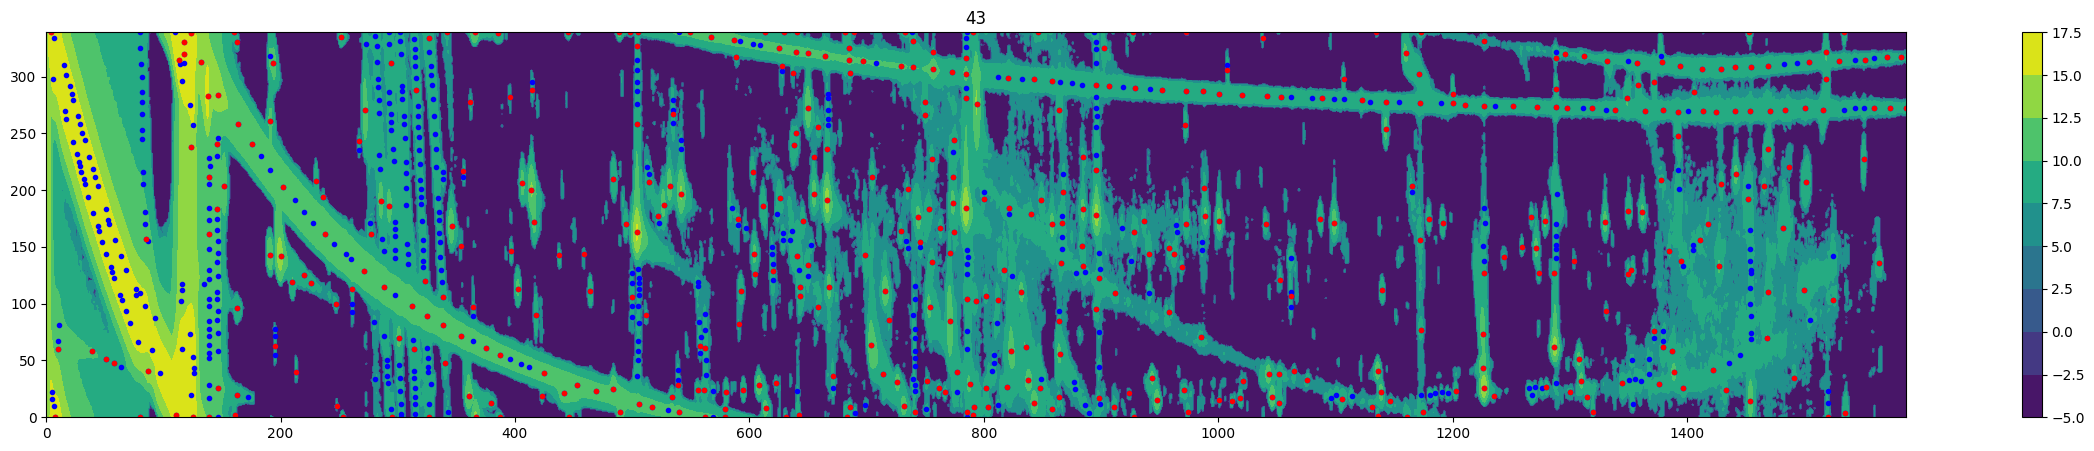

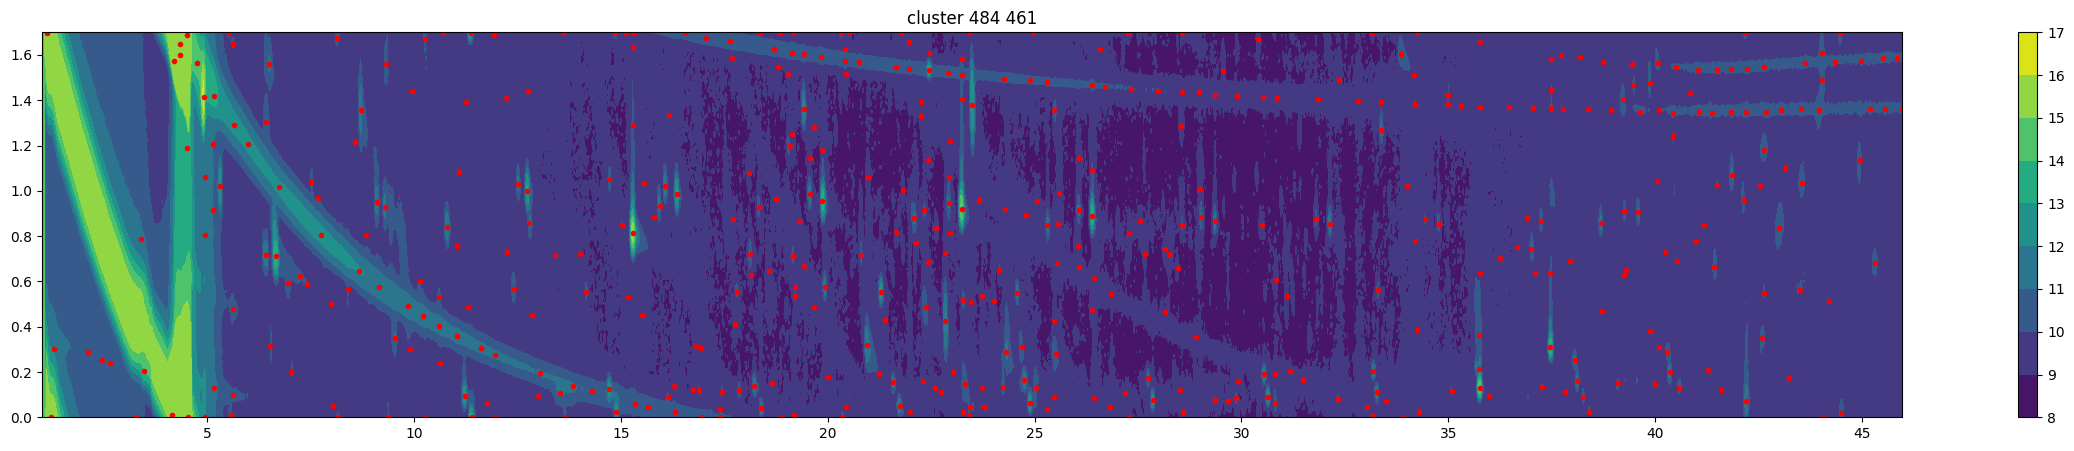

In [ ]:
import baseline_correction

m= 43-35
correct = method_window(chromato_cube[m,:,:],block_size=10,gamma=0.5, lmbd=25) # method 1
#correct = method_als(chromato_cube[m,:,:],  sg_windows=10,lam=10**3,p=0.001) # method 2
#correct = method_poly(chromato_cube[m,:,:]) # method 3

coordinate_before, radius = dbscan_peak.detect_peak_dog(correct, 
                                                        abs_threshold=100,
                        rel_threshold=0.0001,
                        noise_factor=5,
                        min_sigma=1, 
                        max_sigma=3,
                        sigma_ratio=1.1,
                        overlap=0.5)

# peak clusturing
distance_matrix=dbscan_peak.compute_distance_metric(coordinate_before,chromato_cube,1.7,time_rn, 5, 0.1)
coordinates, radius , clusters, clusters_label= dbscan_peak.cluster_peak(distance_matrix,chromato_safe,coordinate_before,radius,0.04,1)

plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
fig, ax = plt.subplots()
contour =ax.contourf(np.log(correct.T))
plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
plt.title(str(m+35))
ax.plot(coordinate_before[:,0], coordinate_before[:,1], "b.")
ax.plot(coordinates[:,0], coordinates[:,1], "r.")
chromato_safe = np.where(chromato_cube[m,:,:] <= 0, min(chromato_cube[m,:,:][chromato_cube[m,:,:]>0]), chromato_cube[m,:,:])
plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coordinate_before)-len(coordinates)) + " " + str(len(coordinates)) , 
                 log_chromato=True,  mod_time=1.7, rt1_window=0.1, rt2_window=0.2,points=coordinates_in_chromato)


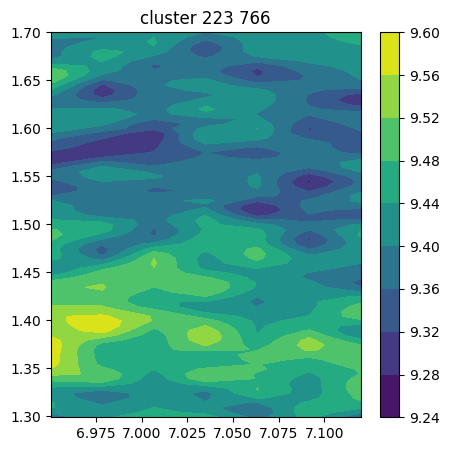

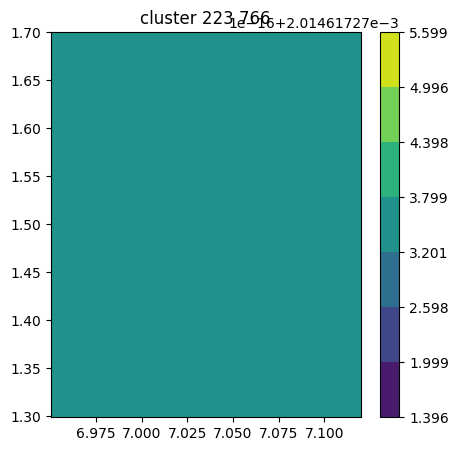

In [ ]:
i=5
plt.rcParams['figure.figsize'] = [5, 5]
plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coordinate_before)-len(coordinates)) + " " + str(len(coordinates)) , log_chromato=True,  mod_time=1.7, rt1_window=0.1, rt2_window=0.4,points=coordinates_in_chromato, 
                 rt1=coordinates_in_chromato[i][0],rt2=coordinates_in_chromato[i][1])
plot.visualizer2((correct,time_rn), title="cluster " + str(len(coordinate_before)-len(coordinates)) + " " + str(len(coordinates)) , log_chromato=False, 
                  mod_time=1.7, rt1_window=0.1, rt2_window=0.4,points=coordinates_in_chromato, 
                 rt1=coordinates_in_chromato[i][0],rt2=coordinates_in_chromato[i][1])

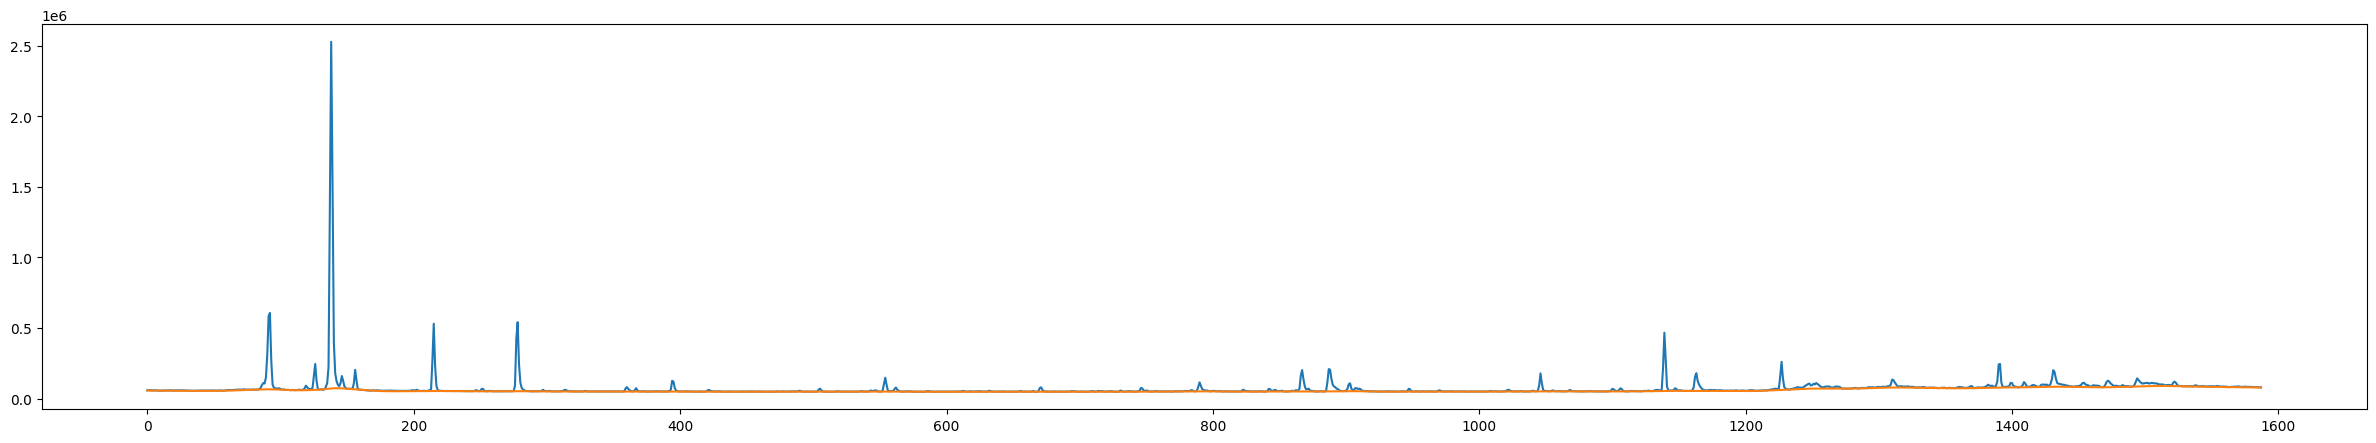

In [110]:
plt.rcParams['figure.figsize'] = [30, 5]
sp=chromato_safe[:,100]
bs=  pybaselines.whittaker.asls(sp,lam=100,p=0.001)[0]
plt.plot(sp)
plt.plot(bs)

In [ ]:
mat = smooth2d(mat, lmbd=lmbd,lmbd2=lmbd)

In [632]:
def compute_bounds(coords, radii):
    """
    Calcule les bornes [min,max] en RT et m/z pour chaque pic
    coords: array (n,2) -> (rt, mz)
    radii: array (n,) -> rayon du blob
    """
    bounds = []
    for (rt, mz), radius in zip(coords, radii):

        rt_radius = radius * 2 * 1.7 / 60
        mz_radius = radius * 6 * 0.005

        rt_min, rt_max = rt - rt_radius, rt + rt_radius
        mz_min, mz_max = mz - mz_radius, mz + mz_radius

        bounds.append([[rt_min, rt_max], [mz_min, mz_max]])

    return np.array(bounds)  # shape (n, 2, 2)

coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
bounds = compute_bounds(coordinates_in_chromato, radius)
clusters = deconvolution.cluster_bounds(coordinates_in_chromato,bounds,time_rn, 1.7,   chromato.shape)
final_bounds = deconvolution.expand_cluster_bounds(bounds, clusters)
print(len(clusters))
max([len(x) for x in clusters]) # mettre max 4 pics 

235


4

In [634]:
res=[]
for j in range(len(clusters)):
   res.append(deconvolution.fit_all_peaks_fixed_centers((correct), coordinates[clusters[j]], projection.chromato_to_matrix(final_bounds[j].T,time_rn, 1.7, chromato.shape).T, plot=False))

In [249]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import numpy as np

coordm = coordinates

# --- Étape 1 : former les groupes par recouvrement de fenêtre ---
rt_vals = projection.matrix_to_chromato(coordm, time_rn, 1.7, chromato.shape)
rt_vals[:, 0] = rt_vals[:, 0] * 60
scaled_rt = rt_vals / np.array([10, 0.15])

# matrice de distances (L1 / Manhattan)
penalty_matrix = 0.01 * cdist(scaled_rt, scaled_rt, metric='cityblock')

clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
labels = clustering.labels_

clusters = []
for i in range(max(labels) + 1):
    clusters.append(np.where(labels == i)[0].tolist())

# --- Étape 2 : subdivision des clusters > 7 ---
final_clusters = []

for cluster in clusters:
    if len(cluster) <= 7:
        final_clusters.append(cluster)
    else:
        # extraire les points du cluster
        sub_coords = scaled_rt[cluster]

        # recalculer matrice de distances pour ce sous-cluster
        sub_penalty_matrix = 0.01 * cdist(sub_coords, sub_coords, metric='cityblock')

        # relancer DBSCAN plus strict
        sub_clustering = DBSCAN(eps=0.005, min_samples=1, metric='precomputed').fit(sub_penalty_matrix)
        sub_labels = sub_clustering.labels_

        for sub_label in set(sub_labels):
            sub_idx = np.where(sub_labels == sub_label)[0]
            sub_cluster = [cluster[i] for i in sub_idx]

            # si encore trop gros (>7), tu pourrais relancer récursivement ici
            if len(sub_cluster) > 7:
                # récursion : appeler la même logique
                # (ici je le fais inline pour simplicité)
                sub_sub_coords = scaled_rt[sub_cluster]
                sub_sub_penalty_matrix = 0.01 * cdist(sub_sub_coords, sub_sub_coords, metric='cityblock')
                sub_sub_clustering = DBSCAN(eps=0.005, min_samples=1, metric='precomputed').fit(sub_sub_penalty_matrix)
                sub_sub_labels = sub_sub_clustering.labels_
                for sub_sub_label in set(sub_sub_labels):
                    idx = np.where(sub_sub_labels == sub_sub_label)[0]
                    final_clusters.append([sub_cluster[j] for j in idx])
            else:
                final_clusters.append(sub_cluster)

# Résultat final
clusters = final_clusters


In [ ]:
[j for j, x in enumerate(clusters) if len(x)>1]

In [ ]:
i=30

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('D:/baseline_test.pdf')  # Open PDF explicitly


for i in range(chromato_cube.shape[0]):
    data_to_smooth = np.sum(chromato_cube[i,:,:],axis=1)
    smoother = WhittakerSmoother(lmbda=1, order=1, data_length=len(data_to_smooth))
    results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=True)
    optimally_smoothed_series = results.get_optimal().get_smoothed()
    optimal_lambda = results.get_optimal().get_lambda()
    print(optimal_lambda)
    if optimal_lambda >50 :
        optimal_lambda=50
    elif optimal_lambda <10:
        optimal_lambda=50
    correct=baseline_correct(chromato_cube[i,:,:],block_size=20, lmbd=optimal_lambda)
    coord, radius = dbscan_peak.detect_peak_dog(correct, abs_threshold=0,
                        rel_threshold=0.001,
                        noise_factor=5,
                        min_sigma=1, max_sigma=8,
                        sigma_ratio=1.1,
                        overlap=0.95)
    distance_matrix=dbscan_peak.compute_distance_metric(coord,chromato_cube,1.7,time_rn,5, 0.1)
    coordinates, clusters= dbscan_peak.cluster_peak(distance_matrix,correct,coord,0.05,min_sample_db_scan=1)
    coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
    fig, ax = plt.subplots()
    contour =ax.contourf(np.log(correct.T))
    plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
    plt.title(str(i+35))
    ax.plot(coord[:,0], coord[:,1], "b.")
    ax.plot(coordinates[:,0], coordinates[:,1], "r.")
    pdf.savefig(fig)
    plt.close(fig)
    chromato_safe = np.where(chromato_cube[i,:,:] <= 0, 0.01, chromato_cube[i,:,:])
    fig=plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coord)-len(coordinates)) + " " , log_chromato=True,  mod_time=1.7, rt1_window=2, rt2_window=1,points=coordinates_in_chromato)
    pdf.savefig(fig)  # Save current figure to PDF
    plt.close(fig)    # Close figure to free memory
    print(str(i) + str(len(coord)-len(coordinates)))
pdf.close()  # Close the PDF file explicitly



In [673]:
pdf.close()

In [ ]:
## group pics for déconvolution 
rt_vals= projection.matrix_to_chromato(coordinates, time_rn,1.7,chromato.shape)
rt_vals[:,0]=rt_vals[:,0]*60
scaled_rt = rt_vals / np.array([6, 0.05])
        
    # Compute Manhattan (L1) distance between all rows
penalty_matrix =0.01* cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)
clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    clusters[clustering.labels_[i]].append(i)
groups=clusters

shape = chromato.shape
mod_time=1.7
X= np.arange(time_rn[0], time_rn[1], mod_time/60)[:-1]
Y = np.linspace(0, mod_time, shape[1])
chromato = np.transpose(chromato)
fig, ax = plt.subplots()
tmp = ax.contourf(X, Y, chromato)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i in range(5):
    points = coordinates_in_chromato[groups[i]]
    ax.plot(points[:, 0], points[:, 1], '.', color=colors[i])
plt

In [ ]:
from dbscan_peak import intensity_threshold_decision_rule

thr=[]
for m in range(chromato_cube.shape[0]) :
    sigma = estimate_sigma(chromato_cube[m,:,:], channel_axis=None)
    intensity_threshold = intensity_threshold_decision_rule(
            500, 0.001, 5, sigma, chromato_cube[m,:,:])
    thr.append(intensity_threshold)

info_par_peak=[]
for item in matches:
    indices_masses=np.where((item[1][0]['spectra'])>thr)[0]
    majority_mass=np.argmax((item[1][0]['spectra']))
    info_par_peak.append((majority_mass, indices_masses))

# Initialiser la liste des masses avec des listes vides
masses_with_peak_indices = [[[],[]] for _ in range(chromato_cube.shape[0])]

# Remplir la structure : pour chaque pic, ajouter son index aux masses correspondantes
for peak_index, peak_info in enumerate(info_par_peak):
    for mass_index in peak_info[1]:
        masses_with_peak_indices[mass_index][1].append(peak_index)
    masses_with_peak_indices[peak_info[0]][0].append(peak_index) # arg max

In [ ]:
[j for j,c in enumerate(coordinates_in_chromato) if 10.22<c[0]<10.36 and 0.15<c[1]<0.45]


In [ ]:
coords= coordinates[[255, 802]]

list_res=[]
for j in list(set(info_par_peak[255][1]) | set(info_par_peak[802][1])) :
    res=fit_all_peaks_fixed_centers(chromato_cube[j,:,:],coords,window_1=3, window_2=20,plot=True)
    list_res.append(res)

In [ ]:
spec_esti = np.zeros(len(matches[328][1][0]['spectra']))  
for j, m in enumerate(list(set(info_par_peak[255][1]) | set(info_par_peak[802][1]))) :
    spec_esti[m]= list_res[j][1]['params'][0]

print(matching_from_spectra(spec_esti))
print(matching_from_spectra(matches[802][1][0]['spectra'] ))

import plotly.graph_objects as go
import numpy as np
import kaleido

# Example spectra data
# Replace these with your actual spectra arrays
spectrum2 = spec_esti  # First spectrum for bar plot
spectrum1 = matches[802][1][0]['spectra']  # Second spectrum for line plot

# Generate x-axis values
x_values = np.arange(len(spectrum1))

# Create the bar plot for the first spectrum
bar_trace = go.Bar(x=x_values, y=spectrum1, name='Original Spectrum')

# Create the line plot for the second spectrum
line_trace = go.Scatter(x=x_values, y=spectrum2, mode='lines', name='Estimated Spectrum', line=dict(color='red'))

# Combine both plots
fig = go.Figure(data=[bar_trace, line_trace])

fig


In [ ]:
coords= np.array([([1283,   85]),
 ([1278,   84]),
 ([1279,   73]),
 ([1280,   60])])

res=fit_all_peaks_fixed_centers(tmp,coords,plot=True)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages('D:/test_deconvo_plot2.pdf') 

mass_with_argmax = list(set([m[0]for m in info_par_peak ]))
for m in mass_with_argmax:
    peak_to_quanti = masses_with_peak_indices[m][0]
    all_peaks= masses_with_peak_indices[m][1]
    for i in peak_to_quanti:
        all_peaks.append(i)
        plt.rcParams['figure.figsize'] = [10, 5]
        fig=plot.visualizer2((chromato_cube[m,:,:],time_rn),mod_time=1.7,rt1=matches[i][0][0],rt2=matches[i][0][1],log_chromato=False,rt1_window=0.1,rt2_window=0.2, points=coordinates_in_chromato[all_peaks],
                            title=f"{m + mass_range[0]} / {i} /{ round(matches[i][0][0],4)}/ {round(matches[i][0][1],4)}", )        
        pdf.savefig(fig)  
        plt.close(fig)    

pdf.close()  

c

In [ ]:
ny, nx = tmp.shape
fitted_results = []
visited = set()
fitted_peak=[]
for i, (cy, cx) in enumerate(coords):
    if (cy, cx) in visited:
        continue

        # Cherche pics proches
    close_indices = [j for j, (yy, xx) in enumerate(coords)
                        if np.hypot(yy - cy, xx - cx) <= 50]
    for j in close_indices:
        visited.add(tuple(coords[j]))

        # Détermine zone globale pour fit
    min_x = max(0, int(min(cx - 40, *(coords[j][1] - 40 for j in close_indices))))
    max_x = min(nx, int(max(cx + 40, *(coords[j][1] + 40 for j in close_indices)))+1)
    min_y = max(0, int(min(cy -4, *(coords[j][0] - 4 for j in close_indices))))
    max_y = min(ny, int(max(cy + 4, *(coords[j][0] +4 for j in close_indices)))+1)

    sub_tmp = tmp[min_y:max_y, min_x:max_x]
    xx, yy = np.meshgrid(np.arange(min_x, max_x), np.arange(min_y, max_y))

        # Paramètres initiaux (sans centres)
    p0 = []
    fixed_centers = []
    for j in close_indices:
        yy0, xx0 = coords[j]
        amp = tmp[yy0, xx0]
        p0.extend([amp, 3, 3, 0, 0])  # no xo, yo here
        fixed_centers.append((yy0, xx0))

        # Fit
    popt, _ = curve_fit(
            lambda crd, *prm: multi_gaussian_fixed_centers(crd, *prm, centers=fixed_centers),
            (xx, yy),
            sub_tmp.ravel(),
            p0=p0
        )

        # Aire pour chaque gaussienne
    n_params = 5
    
    for k, (yy0, xx0) in enumerate(fixed_centers):
        amp, sx, sy, th, off = popt[k*n_params:(k+1)*n_params]
        fitted_peak .append(twoD_Gaussian_asym_fixed_center((xx, yy), amp, sx, sy, th, 0, xx0, yy0).reshape(sub_tmp.shape))
        area = np.sum(fitted_peak)
        fitted_results.append({
                "center": (yy0, xx0),
                "params": (amp, sx, sy, th, off),
                "area": area
            })
